# TB-DOTS CAR CDSS — XGBoost Treatment Outcome Prediction Model

**Gradient Boosted Decision Trees (XGBoost)** for predicting treatment outcome (**Success / Failure**) with confidence scores, using monthly patient monitoring data and baseline clinical features.

### Why XGBoost Instead of LSTM?
| Factor | LSTM | XGBoost |
|--------|------|---------|
| **Dataset size** | Needs thousands+ samples | Excels with small datasets (205 patients) |
| **Sequence length** | Designed for long sequences (50-1000+) | Handles short sequences via feature engineering |
| **Class imbalance** | Struggles without careful tuning | Native `scale_pos_weight` support |
| **Interpretability** | Black box | Built-in feature importance |
| **Overfitting risk** | High with few samples | Regularized by design (max_depth, min_child_weight) |

### Progressive Temporal Prediction
Like the LSTM model, this supports **prediction at any month** (M0–M12). For each month `t`, the model uses:
- **Static features** (51 baseline clinical features)
- **Temporal features up to month t** (flattened: 8 features × (t+1) months)

This means a separate feature vector is constructed per prediction point, enabling early warning at any treatment stage.

### Outputs
- Trained model checkpoint → `models/xgb_best_model.json`
- Evaluation metrics → `models/xgb_evaluation_report.txt`
- Per-patient predictions → `models/xgb_predictions.csv`
- Training curves plot → `models/xgb_training_curves.png`
- Per-month performance → `models/xgb_per_month_performance.png`
- Feature importance → `models/xgb_feature_importance.png`
- LSTM vs XGBoost comparison → `models/model_comparison.png`

## 0. Imports & Configuration

In [6]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)

warnings.filterwarnings("ignore")

# ── Reproducibility ─────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Paths ───────────────────────────────────────────────────────
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "dataset" / "temporal" / "output"
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

print(f"XGBoost: {xgb.__version__}")
print(f"Data   : {DATA_DIR}")
print(f"Models : {MODEL_DIR}")

XGBoost: 3.2.0
Data   : c:\Users\Ven\Documents\thesis-2\TB-DOTS-CAR-CDSS\dataset\temporal\output
Models : c:\Users\Ven\Documents\thesis-2\TB-DOTS-CAR-CDSS\models


## 1. Data Loading & Label Creation

Load the same preprocessed temporal and static arrays. Outcome columns are removed from static features to prevent target leakage. Binary labels:
- **Success (1)** = Cured, Treatment Completed
- **Failure (0)** = Died, Lost to Follow-Up, Not Evaluated

In [7]:
def load_data():
    """Load preprocessed arrays and create binary outcome labels."""

    # --- Temporal features (already scaled) ----------------------
    X_temporal = np.load(DATA_DIR / "X_temporal.npy")  # (205, 13, 8)

    # --- Static features (already encoded & scaled) --------------
    X_static = np.load(DATA_DIR / "X_static.npy")  # (205, 56)
    feature_names = np.load(DATA_DIR / "feature_names.npz", allow_pickle=True)
    static_names = list(feature_names["static"])

    # --- Identify and REMOVE outcome columns (target leakage) ----
    outcome_cols = [
        "outcome_Cured",
        "outcome_Died",
        "outcome_Lost to Follow-Up",
        "outcome_Not Evaluated",
        "outcome_Treatment Completed",
    ]
    outcome_idx = [static_names.index(c) for c in outcome_cols]
    keep_idx = [i for i in range(X_static.shape[1]) if i not in outcome_idx]

    X_static_clean = X_static[:, keep_idx]
    static_names_clean = [static_names[i] for i in keep_idx]

    # --- Build binary labels -------------------------------------
    df = pd.read_csv(DATA_DIR / "cleaned_combined_dataset.csv")
    success_outcomes = {"Cured", "Treatment Completed"}
    y = np.array(
        [1 if o in success_outcomes else 0 for o in df["outcome"]],
        dtype=np.float32,
    )

    # --- Temporal feature names ----------------------------------
    temporal_names = [
        "cumulative_doses_taken", "height",
        "monthly_doses_taken", "monthly_missed_doses",
        "pct_adherence", "smear_tb_lamp", "weight", "xpert_mtb_rif",
    ]

    print(f"Temporal features : {X_temporal.shape}")
    print(f"Static features   : {X_static_clean.shape}  (outcome cols removed)")
    print(f"Labels            : {y.shape}  "
          f"(Success={int(y.sum())}, Failure={int(len(y) - y.sum())})")

    return X_temporal, X_static_clean, y, static_names_clean, temporal_names, df


X_temporal, X_static, y, static_names, temporal_names, df = load_data()

Temporal features : (205, 13, 8)
Static features   : (205, 51)  (outcome cols removed)
Labels            : (205,)  (Success=188, Failure=17)


## 2. Feature Engineering for XGBoost

XGBoost requires flat 2D input, so we transform the 3D temporal data into meaningful engineered features at each prediction month. For month `t`, we compute:

**From temporal data (M0..Mt):**
- Raw features at each available month (flattened)
- **Aggregates**: mean, std, min, max of key temporal features across available months
- **Trend features**: slope of weight, adherence, and cumulative doses over time
- **Latest values**: most recent month's readings

This gives XGBoost rich temporal information without needing a recurrent architecture.

In [8]:
def build_features_at_month(X_temporal, X_static, up_to_month, temporal_names, static_names):
    """
    Build a flat feature matrix for XGBoost using data up to `up_to_month`.

    Features include:
    1. Static baseline features (always the same)
    2. Flattened raw temporal features up to month t
    3. Aggregate stats (mean, std, min, max) over available months
    4. Trend (linear slope) of key features
    5. Latest month's values
    6. Month indicator (how much data is available)

    Returns: X_flat (n_patients, n_features), feature_name_list
    """
    n_patients = X_temporal.shape[0]
    n_temporal_feats = X_temporal.shape[2]  # 8
    valid_months = up_to_month + 1

    feature_list = []
    feature_name_list = []

    # 1. Static features (always included)
    feature_list.append(X_static)
    feature_name_list.extend(static_names)

    # 2. Flattened temporal features for months 0..up_to_month
    temporal_flat = X_temporal[:, :valid_months, :].reshape(n_patients, -1)
    for m in range(valid_months):
        for feat in temporal_names:
            feature_name_list.append(f"M{m}_{feat}")
    feature_list.append(temporal_flat)

    # 3. Aggregate statistics over available months
    temporal_slice = X_temporal[:, :valid_months, :]  # (N, valid_months, 8)
    for agg_name, agg_fn in [("mean", np.mean), ("std", np.std),
                              ("min", np.min), ("max", np.max)]:
        agg = agg_fn(temporal_slice, axis=1)  # (N, 8)
        feature_list.append(agg)
        for feat in temporal_names:
            feature_name_list.append(f"{agg_name}_{feat}")

    # 4. Trend features (linear slope) for key temporal features
    if valid_months >= 2:
        slopes = np.zeros((n_patients, n_temporal_feats))
        x_time = np.arange(valid_months, dtype=np.float32)
        for i in range(n_patients):
            for j in range(n_temporal_feats):
                vals = temporal_slice[i, :, j]
                if np.std(vals) > 1e-8:
                    slope = np.polyfit(x_time, vals, 1)[0]
                else:
                    slope = 0.0
                slopes[i, j] = slope
        feature_list.append(slopes)
        for feat in temporal_names:
            feature_name_list.append(f"trend_{feat}")
    else:
        # With only M0, slope is 0
        feature_list.append(np.zeros((n_patients, n_temporal_feats)))
        for feat in temporal_names:
            feature_name_list.append(f"trend_{feat}")

    # 5. Latest month's values
    latest = X_temporal[:, up_to_month, :]  # (N, 8)
    feature_list.append(latest)
    for feat in temporal_names:
        feature_name_list.append(f"latest_{feat}")

    # 6. Month indicator
    month_indicator = np.full((n_patients, 1), up_to_month, dtype=np.float32)
    feature_list.append(month_indicator)
    feature_name_list.append("months_available")

    X_flat = np.hstack(feature_list).astype(np.float32)
    # Replace any NaN from std calculations (single-month std = nan)
    X_flat = np.nan_to_num(X_flat, nan=0.0)

    return X_flat, feature_name_list


# Demo: build features at M12 (full data) to check dimensions
X_full, feat_names_full = build_features_at_month(
    X_temporal, X_static, up_to_month=12,
    temporal_names=temporal_names, static_names=static_names
)
print(f"Full feature matrix (M12): {X_full.shape}")
print(f"Number of features: {len(feat_names_full)}")
print(f"\nFeature name samples:")
print(f"  Static:    {feat_names_full[:3]}")
print(f"  Temporal:  {feat_names_full[len(static_names):len(static_names)+3]}")
print(f"  Aggregate: {[f for f in feat_names_full if f.startswith('mean_')][:3]}")
print(f"  Trend:     {[f for f in feat_names_full if f.startswith('trend_')][:3]}")
print(f"  Latest:    {[f for f in feat_names_full if f.startswith('latest_')][:3]}")

Full feature matrix (M12): (205, 204)
Number of features: 204

Feature name samples:
  Static:    ['age', 'xpert_mtb_rif', 'smear_microscopy']
  Temporal:  ['M0_cumulative_doses_taken', 'M0_height', 'M0_monthly_doses_taken']
  Aggregate: ['mean_cumulative_doses_taken', 'mean_height', 'mean_monthly_doses_taken']
  Trend:     ['trend_cumulative_doses_taken', 'trend_height', 'trend_monthly_doses_taken']
  Latest:    ['latest_cumulative_doses_taken', 'latest_height', 'latest_monthly_doses_taken']


## 3. Patient-Level Train/Val/Test Split

Same 70/20/10 patient-level split as the LSTM model (same random seed) for a fair comparison. Split is done on patients first, then features are built per month as needed.

In [9]:
def split_patients(y, seed=42):
    """
    Split patients 70/20/10 — same split as LSTM model for fair comparison.
    Returns patient indices for train, val, test.
    """
    indices = np.arange(len(y))

    # First split: 70% train, 30% temp
    train_idx, rest_idx = train_test_split(
        indices, test_size=0.30, random_state=seed, stratify=y
    )
    # Second split: 20% val, 10% test
    val_idx, test_idx = train_test_split(
        rest_idx, test_size=1 / 3, random_state=seed, stratify=y[rest_idx]
    )

    for name, idx in [("Train", train_idx), ("Val", val_idx), ("Test", test_idx)]:
        yi = y[idx]
        print(f"  {name:>5s}: {len(idx)} patients  "
              f"(Success={int(yi.sum())}, Failure={int(len(yi) - yi.sum())})")

    return train_idx, val_idx, test_idx


print("Patient split (identical to LSTM model):")
train_idx, val_idx, test_idx = split_patients(y, seed=SEED)

Patient split (identical to LSTM model):
  Train: 143 patients  (Success=131, Failure=12)
    Val: 41 patients  (Success=38, Failure=3)
   Test: 21 patients  (Success=19, Failure=2)


## 4. XGBoost Training with Progressive Temporal Data

Train XGBoost on **progressive temporal data**: for each patient, we create training samples at every month M0–M12. At each month, the feature vector includes:
- All static features
- Temporal features up to that month (engineered: raw + aggregates + trends)

This matches the LSTM's progressive training approach, teaching the model to predict from partial data.

**Hyperparameters** are chosen to avoid overfitting on the small dataset:
- `max_depth=4` (shallow trees)
- `min_child_weight=3` (requires minimum samples per leaf)
- `subsample=0.8`, `colsample_bytree=0.8` (bagging)
- `scale_pos_weight` (handles class imbalance)
- `n_estimators=300` with early stopping

In [10]:
def build_progressive_data(X_temporal, X_static, y, patient_indices,
                          temporal_names, static_names,
                          min_month=0, max_month=12):
    """
    Build progressive training data: for each patient in patient_indices,
    create one sample per month from min_month to max_month.

    Because XGBoost needs a fixed feature width, we always build features
    as if we have data up to M12 (max possible), but zero-pad future months.
    The feature engineering handles this gracefully via aggregates/trends.
    """
    all_X = []
    all_y = []

    for month in range(min_month, max_month + 1):
        # Build features using only data up to this month
        X_month, feat_names = build_features_at_month(
            X_temporal[patient_indices],
            X_static[patient_indices],
            up_to_month=month,
            temporal_names=temporal_names,
            static_names=static_names,
        )
        all_X.append(X_month)
        all_y.append(y[patient_indices])

    # Note: feature count varies per month because flattened temporal size differs.
    # We'll use a FIXED feature set (M12) and pad shorter months.
    # Better approach: train one model per month, or use the max-month feature set.
    return all_X, all_y, feat_names


def train_xgboost(X_temporal, X_static, y, train_idx, val_idx,
                   temporal_names, static_names):
    """
    Train XGBoost with progressive temporal data.

    Strategy: Train a separate model per month group (early M0-M3,
    mid M4-M8, late M9-M12) for better specialization, OR train
    one unified model on M12 features and evaluate at each month.

    We use the unified approach for simplicity: train on full M12
    features, then at inference time build features up to month t
    (padding the rest with zeros).
    """
    # Build full-length (M12) features for train and val
    X_train_full, feat_names = build_features_at_month(
        X_temporal[train_idx], X_static[train_idx],
        up_to_month=12,
        temporal_names=temporal_names,
        static_names=static_names,
    )
    y_train = y[train_idx]

    X_val_full, _ = build_features_at_month(
        X_temporal[val_idx], X_static[val_idx],
        up_to_month=12,
        temporal_names=temporal_names,
        static_names=static_names,
    )
    y_val = y[val_idx]

    # Also build progressive train data (M0–M12 for each patient)
    # This gives 143 patients × 13 months = 1,859 training samples
    X_train_prog = []
    y_train_prog = []
    for month in range(13):
        X_m, fn = build_features_at_month(
            X_temporal[train_idx], X_static[train_idx],
            up_to_month=month,
            temporal_names=temporal_names,
            static_names=static_names,
        )
        # Pad to match M12 feature width
        if X_m.shape[1] < X_train_full.shape[1]:
            pad_width = X_train_full.shape[1] - X_m.shape[1]
            X_m = np.hstack([X_m, np.zeros((X_m.shape[0], pad_width), dtype=np.float32)])
        X_train_prog.append(X_m)
        y_train_prog.append(y[train_idx])

    X_train_all = np.vstack(X_train_prog)
    y_train_all = np.concatenate(y_train_prog)

    # Pad validation to M12 width (already M12, so no padding needed)
    print(f"Progressive training samples: {X_train_all.shape[0]} "
          f"({len(train_idx)} patients × 13 months)")
    print(f"Feature dimensions: {X_train_all.shape[1]}")
    print(f"Validation samples: {X_val_full.shape[0]}")

    # Class imbalance weight
    n_pos = y_train_all.sum()
    n_neg = len(y_train_all) - n_pos
    scale_pos_weight = n_neg / n_pos

    print(f"\nClass balance: Success={int(n_pos)}, Failure={int(n_neg)}, "
          f"scale_pos_weight={scale_pos_weight:.2f}")

    # ── XGBoost model ────────────────────────────────────────────
    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,       # L1 regularization
        reg_lambda=1.0,      # L2 regularization
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        early_stopping_rounds=20,
        random_state=SEED,
        use_label_encoder=False,
        verbosity=0,
    )

    # Train with early stopping on validation set
    model.fit(
        X_train_all, y_train_all,
        eval_set=[(X_train_all, y_train_all), (X_val_full, y_val)],
        verbose=False,
    )

    # Get training history
    results = model.evals_result()
    history = {
        "train_loss": results["validation_0"]["logloss"],
        "val_loss": results["validation_1"]["logloss"],
    }

    # Save model
    model.save_model(str(MODEL_DIR / "xgb_best_model.json"))
    print(f"\nBest iteration: {model.best_iteration} / {model.n_estimators}")
    print(f"Model saved to models/xgb_best_model.json")

    return model, history, feat_names


xgb_model, history, feature_names_xgb = train_xgboost(
    X_temporal, X_static, y, train_idx, val_idx,
    temporal_names, static_names
)

Progressive training samples: 1859 (143 patients × 13 months)
Feature dimensions: 204
Validation samples: 41

Class balance: Success=1703, Failure=156, scale_pos_weight=0.09

Best iteration: 269 / 300
Model saved to models/xgb_best_model.json


### Training Curves

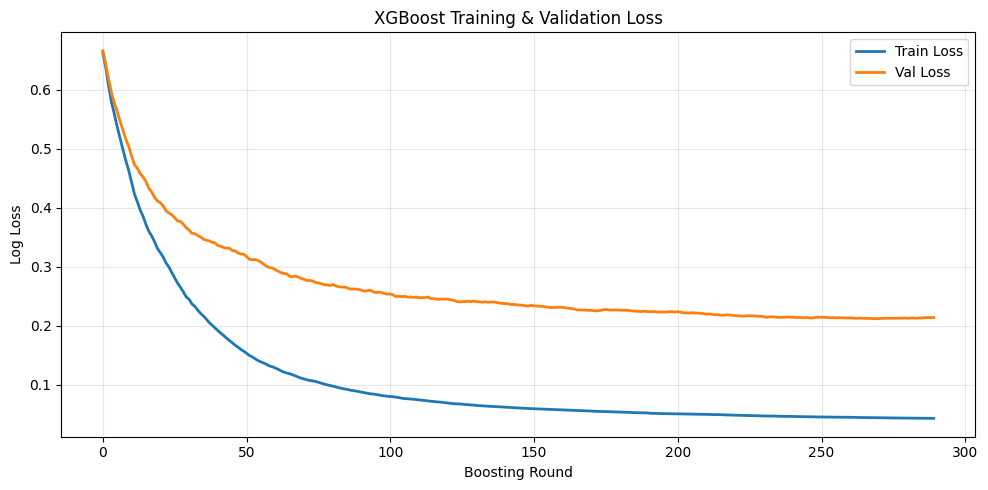

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history["train_loss"], label="Train Loss", linewidth=2)
ax.plot(history["val_loss"], label="Val Loss", linewidth=2)
ax.set_xlabel("Boosting Round")
ax.set_ylabel("Log Loss")
ax.set_title("XGBoost Training & Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_DIR / "xgb_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Evaluation on Test Set

Evaluate the trained XGBoost model on the held-out **10% test set** using full M0–M12 data.

In [12]:
def predict_at_month_xgb(model, X_temporal_subset, X_static_subset,
                        up_to_month, temporal_names, static_names,
                        n_features_full):
    """
    Generate predictions using data up to a specific month.
    Pads feature vector to match the full M12 width the model was trained on.
    """
    X_month, _ = build_features_at_month(
        X_temporal_subset, X_static_subset,
        up_to_month=up_to_month,
        temporal_names=temporal_names,
        static_names=static_names,
    )
    # Pad to match M12 feature width
    if X_month.shape[1] < n_features_full:
        pad_width = n_features_full - X_month.shape[1]
        X_month = np.hstack([X_month, np.zeros((X_month.shape[0], pad_width),
                                                dtype=np.float32)])
    probs = model.predict_proba(X_month)[:, 1]
    preds = (probs >= 0.5).astype(int)
    return probs, preds


def evaluate_model_xgb(model, X_temporal, X_static, y, test_idx,
                       temporal_names, static_names, n_features_full):
    """Full evaluation on held-out test set using M12 data."""

    probs, preds = predict_at_month_xgb(
        model, X_temporal[test_idx], X_static[test_idx],
        up_to_month=12,
        temporal_names=temporal_names,
        static_names=static_names,
        n_features_full=n_features_full,
    )
    labels = y[test_idx]

    metrics = {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "specificity": recall_score(labels, preds, pos_label=0, zero_division=0),
    }
    try:
        metrics["roc_auc"] = roc_auc_score(labels, probs)
    except ValueError:
        metrics["roc_auc"] = float("nan")
    try:
        metrics["pr_auc"] = average_precision_score(labels, probs)
    except ValueError:
        metrics["pr_auc"] = float("nan")

    cm = confusion_matrix(labels, preds)
    return probs, preds, labels, metrics, cm


# Number of features at M12 (the width the model expects)
n_features_full = build_features_at_month(
    X_temporal[:1], X_static[:1], 12, temporal_names, static_names
)[0].shape[1]

probs, preds, labels, metrics, cm = evaluate_model_xgb(
    xgb_model, X_temporal, X_static, y, test_idx,
    temporal_names, static_names, n_features_full
)

print("┌──────────────────────────────────────────┐")
print("│   XGBOOST TEST SET EVALUATION RESULTS     │")
print("│   (Full M0–M12 features)                  │")
print("├──────────────────────────────────────────┤")
for k, v in metrics.items():
    print(f"│  {k:<14s} : {v:>8.4f}               │")
print("└──────────────────────────────────────────┘")
print(f"\nConfusion Matrix:\n{cm}")
print(f"\n{classification_report(labels, preds, target_names=['Failure', 'Success'], zero_division=0)}")

┌──────────────────────────────────────────┐
│   XGBOOST TEST SET EVALUATION RESULTS     │
│   (Full M0–M12 features)                  │
├──────────────────────────────────────────┤
│  accuracy       :   0.8095               │
│  precision      :   0.8947               │
│  recall         :   0.8947               │
│  f1             :   0.8947               │
│  specificity    :   0.0000               │
│  roc_auc        :   0.5789               │
│  pr_auc         :   0.9501               │
└──────────────────────────────────────────┘

Confusion Matrix:
[[ 0  2]
 [ 2 17]]

              precision    recall  f1-score   support

     Failure       0.00      0.00      0.00         2
     Success       0.89      0.89      0.89        19

    accuracy                           0.81        21
   macro avg       0.45      0.45      0.45        21
weighted avg       0.81      0.81      0.81        21



### Evaluation Plots (ROC, PR Curve, Confusion Matrix)

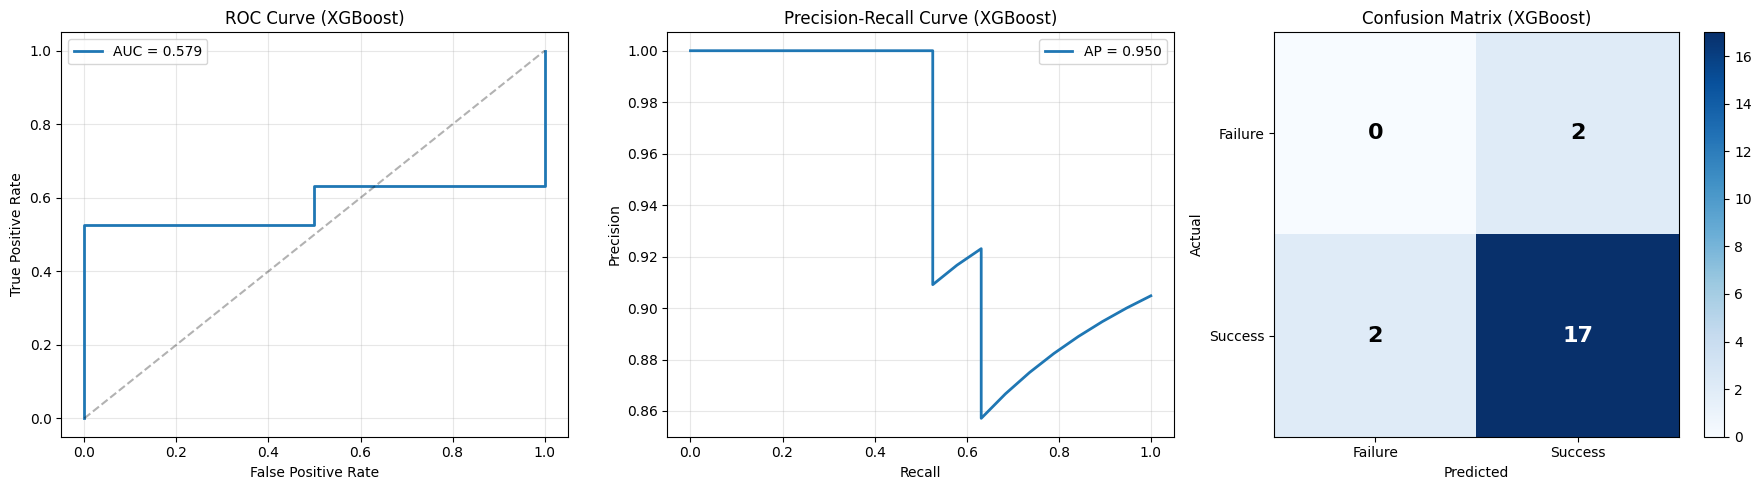

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve
try:
    fpr, tpr, _ = roc_curve(labels, probs)
    auc_val = roc_auc_score(labels, probs)
    axes[0].plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_val:.3f}")
    axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC Curve (XGBoost)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
except ValueError:
    axes[0].text(0.5, 0.5, "Insufficient data\nfor ROC", ha="center", va="center")

# Precision-Recall Curve
try:
    prec, rec, _ = precision_recall_curve(labels, probs)
    ap = average_precision_score(labels, probs)
    axes[1].plot(rec, prec, linewidth=2, label=f"AP = {ap:.3f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision-Recall Curve (XGBoost)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
except ValueError:
    axes[1].text(0.5, 0.5, "Insufficient data\nfor PR", ha="center", va="center")

# Confusion Matrix
im = axes[2].imshow(cm, cmap="Blues", interpolation="nearest")
axes[2].set_title("Confusion Matrix (XGBoost)")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")
axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(["Failure", "Success"])
axes[2].set_yticklabels(["Failure", "Success"])
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(cm[i][j]),
                     ha="center", va="center",
                     color="white" if cm[i][j] > cm.max() / 2 else "black",
                     fontsize=16, fontweight="bold")
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.savefig(MODEL_DIR / "xgb_evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Feature Importance

A key advantage of XGBoost over LSTM — built-in feature importance reveals **which clinical factors matter most** for predicting treatment outcome. This is crucial for a CDSS where clinicians need to understand *why* a prediction was made.

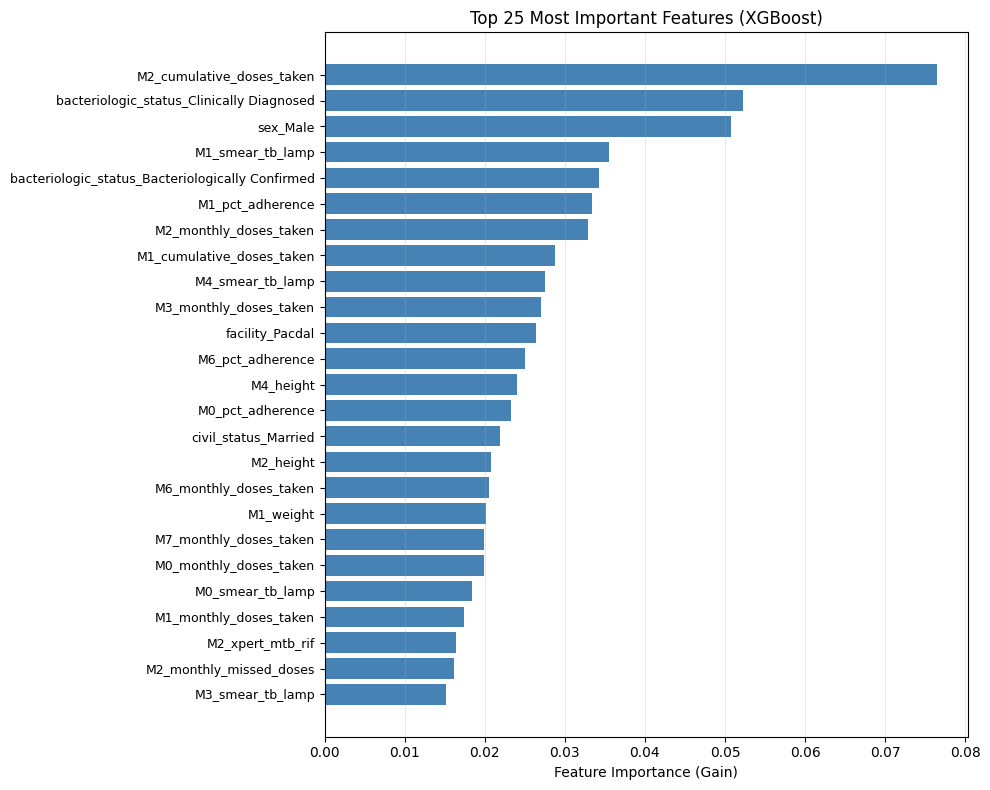


Feature importance by category:
  Static (baseline)             : 0.2739 (27.4%)
  Temporal (raw monthly)        : 0.7261 (72.6%)
  Aggregate (mean/std/min/max)  : 0.0000 (0.0%)
  Trend (slopes)                : 0.0000 (0.0%)
  Latest month                  : 0.0000 (0.0%)


In [14]:
# Get feature importance
importances = xgb_model.feature_importances_

# Map importance to feature names (use M12 feature names)
# Pad feature names if model has more features
if len(feature_names_xgb) < len(importances):
    feature_names_xgb_padded = feature_names_xgb + [
        f"pad_{i}" for i in range(len(importances) - len(feature_names_xgb))
    ]
else:
    feature_names_xgb_padded = feature_names_xgb[:len(importances)]

importance_df = pd.DataFrame({
    "feature": feature_names_xgb_padded,
    "importance": importances
}).sort_values("importance", ascending=False)

# Top 25 features
top_n = 25
top_features = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(range(top_n), top_features["importance"].values[::-1], color="steelblue")
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features["feature"].values[::-1], fontsize=9)
ax.set_xlabel("Feature Importance (Gain)")
ax.set_title(f"Top {top_n} Most Important Features (XGBoost)")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(MODEL_DIR / "xgb_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Categorize feature importance
print("\nFeature importance by category:")
categories = {
    "Static (baseline)": [f for f in importance_df["feature"] if not any(
        f.startswith(p) for p in ["M", "mean_", "std_", "min_", "max_",
                                   "trend_", "latest_", "months_"])],
    "Temporal (raw monthly)": [f for f in importance_df["feature"] if f[:1] == "M" and "_" in f],
    "Aggregate (mean/std/min/max)": [f for f in importance_df["feature"]
                                       if any(f.startswith(p) for p in ["mean_", "std_", "min_", "max_"])],
    "Trend (slopes)": [f for f in importance_df["feature"] if f.startswith("trend_")],
    "Latest month": [f for f in importance_df["feature"] if f.startswith("latest_")],
}

for cat_name, cat_features in categories.items():
    cat_importance = importance_df[importance_df["feature"].isin(cat_features)]["importance"].sum()
    print(f"  {cat_name:<30s}: {cat_importance:.4f} "
          f"({cat_importance / importances.sum() * 100:.1f}%)")

## 7. CDSS Predictions

Generate per-patient predictions with **confidence scores** and **risk levels** for all 205 patients using full M0–M12 data.

In [15]:
def generate_cdss_predictions_xgb(model, X_temporal_all, X_static_all, df,
                                  up_to_month, temporal_names, static_names,
                                  n_features_full):
    """Generate per-patient CDSS predictions with confidence and risk levels."""

    probs, preds_binary = predict_at_month_xgb(
        model, X_temporal_all, X_static_all,
        up_to_month=up_to_month,
        temporal_names=temporal_names,
        static_names=static_names,
        n_features_full=n_features_full,
    )

    results = []
    for i in range(len(df)):
        prob_success = float(probs[i])
        prob_failure = 1.0 - prob_success
        predicted_class = "Success" if prob_success >= 0.5 else "Failure"
        confidence = max(prob_success, prob_failure) * 100

        if prob_failure >= 0.7:
            risk_level = "HIGH RISK"
        elif prob_failure >= 0.4:
            risk_level = "MODERATE RISK"
        else:
            risk_level = "LOW RISK"

        results.append({
            "patient_idx": i,
            "treatment_regimen": df.iloc[i].get("treatment_regimen", "N/A"),
            "actual_outcome": df.iloc[i]["outcome"],
            "predicted_outcome": predicted_class,
            "prob_success": round(prob_success, 4),
            "prob_failure": round(prob_failure, 4),
            "confidence_pct": round(confidence, 2),
            "risk_level": risk_level,
            "months_used": f"M0-M{up_to_month}",
        })

    return pd.DataFrame(results)


predictions_df = generate_cdss_predictions_xgb(
    xgb_model, X_temporal, X_static, df,
    up_to_month=12,
    temporal_names=temporal_names,
    static_names=static_names,
    n_features_full=n_features_full,
)
predictions_df.to_csv(MODEL_DIR / "xgb_predictions.csv", index=False)

print(f"Predictions saved to models/xgb_predictions.csv")
print(f"\nRisk Level Distribution:")
print(predictions_df["risk_level"].value_counts())
print(f"\nSample predictions:")
predictions_df.head(10)

Predictions saved to models/xgb_predictions.csv

Risk Level Distribution:
risk_level
LOW RISK         190
HIGH RISK         13
MODERATE RISK      2
Name: count, dtype: int64

Sample predictions:


,patient_idx,treatment_regimen,actual_outcome,predicted_outcome,prob_success,prob_failure,confidence_pct,risk_level,months_used
0,0,Regimen 1,Died,Failure,0.0239,0.9761,97.61,HIGH RISK,M0-M12
1,1,Regimen 1,Treatment Completed,Success,0.9308,0.0692,93.08,LOW RISK,M0-M12
2,2,Regimen 1,Cured,Success,0.9960,0.0040,99.60,LOW RISK,M0-M12
3,3,Regimen 1,Treatment Completed,Success,0.9912,0.0088,99.12,LOW RISK,M0-M12
4,4,Regimen 1,Treatment Completed,Success,0.9907,0.0093,99.07,LOW RISK,M0-M12
5,5,Regimen 1,Treatment Completed,Success,0.9690,0.0310,96.90,LOW RISK,M0-M12
6,6,Regimen 1,Treatment Completed,Success,0.9837,0.0163,98.37,LOW RISK,M0-M12
7,7,Regimen 1,Treatment Completed,Success,0.9941,0.0059,99.41,LOW RISK,M0-M12
8,8,Regimen 1,Treatment Completed,Success,0.9918,0.0082,99.18,LOW RISK,M0-M12
9,9,Regimen 1,Treatment Completed,Success,0.9839,0.0161,98.39,LOW RISK,M0-M12


## 8. CDSS Early Warning — Predict at Any Month

Demonstrate progressive prediction for a single patient, showing how confidence evolves as more monthly data becomes available.

In [16]:
print("CDSS DEMO — Progressive Early Warning for Patient 0 (XGBoost)")
print(f"Actual outcome: {df.iloc[0]['outcome']}")
print(f"Regimen: {df.iloc[0]['treatment_regimen']}")
print("=" * 65)
print()

for month in range(0, 13):
    # Build features for this single patient up to this month
    probs_m, _ = predict_at_month_xgb(
        xgb_model,
        X_temporal[0:1], X_static[0:1],
        up_to_month=month,
        temporal_names=temporal_names,
        static_names=static_names,
        n_features_full=n_features_full,
    )
    prob_s = probs_m[0]
    confidence = max(prob_s, 1 - prob_s) * 100
    predicted = "Success" if prob_s >= 0.5 else "Failure"
    bar = "█" * int(prob_s * 30)
    print(f"  After M{month:>2d}: {predicted:<8s}  "
          f"Confidence={confidence:>5.1f}%  "
          f"P(Success)={prob_s:.3f}  {bar}")

CDSS DEMO — Progressive Early Warning for Patient 0 (XGBoost)
Actual outcome: Died
Regimen: Regimen 1

  After M 0: Failure   Confidence= 85.5%  P(Success)=0.145  ████
  After M 1: Failure   Confidence= 95.9%  P(Success)=0.041  █
  After M 2: Failure   Confidence= 97.6%  P(Success)=0.024  
  After M 3: Failure   Confidence= 97.9%  P(Success)=0.021  
  After M 4: Failure   Confidence= 97.2%  P(Success)=0.028  
  After M 5: Failure   Confidence= 97.9%  P(Success)=0.021  
  After M 6: Failure   Confidence= 97.7%  P(Success)=0.023  
  After M 7: Failure   Confidence= 97.6%  P(Success)=0.024  
  After M 8: Failure   Confidence= 97.6%  P(Success)=0.024  
  After M 9: Failure   Confidence= 97.6%  P(Success)=0.024  
  After M10: Failure   Confidence= 97.6%  P(Success)=0.024  
  After M11: Failure   Confidence= 97.6%  P(Success)=0.024  
  After M12: Failure   Confidence= 97.6%  P(Success)=0.024  


### Per-Month Prediction Accuracy (Temporal Evaluation)

Evaluate prediction quality at each month M0–M12 across all test patients — directly comparable to the LSTM's per-month evaluation.

Per-month prediction performance on TEST patients (XGBoost):
month  accuracy       f1      auc  n_correct  n_total
   M0  0.809524 0.894737 0.368421         17       21
   M1  0.809524 0.894737 0.473684         17       21
   M2  0.809524 0.894737 0.421053         17       21
   M3  0.809524 0.894737 0.447368         17       21
   M4  0.809524 0.894737 0.447368         17       21
   M5  0.809524 0.894737 0.447368         17       21
   M6  0.809524 0.894737 0.526316         17       21
   M7  0.809524 0.894737 0.552632         17       21
   M8  0.809524 0.894737 0.552632         17       21
   M9  0.809524 0.894737 0.578947         17       21
  M10  0.809524 0.894737 0.578947         17       21
  M11  0.809524 0.894737 0.578947         17       21
  M12  0.809524 0.894737 0.578947         17       21


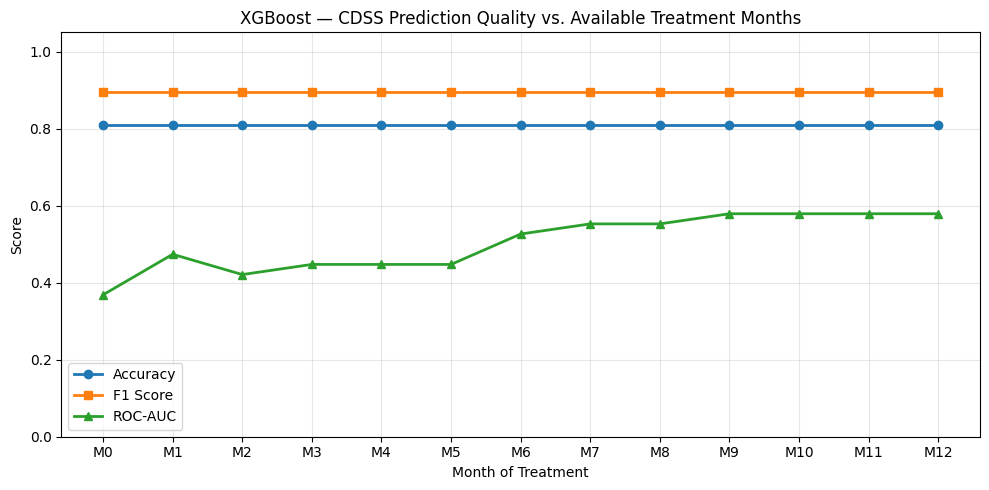

In [17]:
def evaluate_per_month_xgb(model, X_temporal_subset, X_static_subset,
                           y_subset, temporal_names, static_names,
                           n_features_full):
    """Evaluate model accuracy at each month (M0–M12) for test patients."""
    month_metrics = []

    for month in range(13):
        probs, preds = predict_at_month_xgb(
            model, X_temporal_subset, X_static_subset,
            up_to_month=month,
            temporal_names=temporal_names,
            static_names=static_names,
            n_features_full=n_features_full,
        )

        acc = accuracy_score(y_subset, preds)
        f1 = f1_score(y_subset, preds, zero_division=0)
        try:
            auc = roc_auc_score(y_subset, probs)
        except ValueError:
            auc = float("nan")

        month_metrics.append({
            "month": f"M{month}",
            "accuracy": acc,
            "f1": f1,
            "auc": auc,
            "n_correct": int((preds == y_subset).sum()),
            "n_total": len(y_subset),
        })

    return pd.DataFrame(month_metrics)


test_temporal = X_temporal[test_idx]
test_static = X_static[test_idx]
test_labels = y[test_idx]

monthly_perf = evaluate_per_month_xgb(
    xgb_model, test_temporal, test_static, test_labels,
    temporal_names, static_names, n_features_full
)
print("Per-month prediction performance on TEST patients (XGBoost):")
print(monthly_perf.to_string(index=False))

# Plot per-month metrics
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(13), monthly_perf["accuracy"], "o-", label="Accuracy", linewidth=2)
ax.plot(range(13), monthly_perf["f1"], "s-", label="F1 Score", linewidth=2)
ax.plot(range(13), monthly_perf["auc"], "^-", label="ROC-AUC", linewidth=2)
ax.set_xlabel("Month of Treatment")
ax.set_ylabel("Score")
ax.set_title("XGBoost — CDSS Prediction Quality vs. Available Treatment Months")
ax.set_xticks(range(13))
ax.set_xticklabels([f"M{i}" for i in range(13)])
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig(MODEL_DIR / "xgb_per_month_performance.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Cross-Validation (Robustness Check)

With only 205 patients, a single train/test split can be unreliable. Stratified 5-fold cross-validation provides a more robust estimate of model performance.

In [18]:
# Build full M12 features for all patients
X_all_full, _ = build_features_at_month(
    X_temporal, X_static, up_to_month=12,
    temporal_names=temporal_names, static_names=static_names
)

# Class weight
n_pos = y.sum()
n_neg = len(y) - n_pos
spw = n_neg / n_pos

cv_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=spw,
    eval_metric="logloss",
    random_state=SEED,
    use_label_encoder=False,
    verbosity=0,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scoring_metrics = ["accuracy", "f1", "roc_auc", "precision", "recall"]
print("5-Fold Stratified Cross-Validation Results (M12 features):")
print("-" * 55)

cv_results = {}
for metric in scoring_metrics:
    scores = cross_val_score(cv_model, X_all_full, y, cv=cv, scoring=metric)
    cv_results[metric] = scores
    print(f"  {metric:<12s}: {scores.mean():.4f} ± {scores.std():.4f}  "
          f"(folds: {', '.join(f'{s:.3f}' for s in scores)})")

print(f"\nCompare with LSTM test results:")
print(f"  LSTM  ROC-AUC: 0.1579  (single test split)")
print(f"  XGB   ROC-AUC: {cv_results['roc_auc'].mean():.4f} ± {cv_results['roc_auc'].std():.4f}  (5-fold CV)")

5-Fold Stratified Cross-Validation Results (M12 features):
-------------------------------------------------------
  accuracy    : 0.7756 ± 0.0730  (folds: 0.707, 0.707, 0.902, 0.805, 0.756)
  f1          : 0.8630 ± 0.0477  (folds: 0.818, 0.818, 0.944, 0.886, 0.848)
  roc_auc     : 0.7525 ± 0.1317  (folds: 0.686, 0.581, 0.978, 0.728, 0.789)
  precision   : 0.9662 ± 0.0309  (folds: 0.931, 0.931, 1.000, 0.969, 1.000)
  recall      : 0.7814 ± 0.0653  (folds: 0.730, 0.730, 0.895, 0.816, 0.737)

Compare with LSTM test results:
  LSTM  ROC-AUC: 0.1579  (single test split)
  XGB   ROC-AUC: 0.7525 ± 0.1317  (5-fold CV)


## 10. LSTM vs XGBoost Comparison

Side-by-side comparison of both models on the same test set and patient split.

      MODEL COMPARISON: Bi-LSTM vs XGBoost
      (Same 70/20/10 patient split, same test set)
Metric               Bi-LSTM     XGBoost      Winner
-----------------------------------------------------------------
  accuracy            0.9048      0.8095      LSTM ◄
  precision           0.9048      0.8947      LSTM ◄
  recall              1.0000      0.8947      LSTM ◄
  f1                  0.9500      0.8947      LSTM ◄
  specificity         0.0000      0.0000       Tie
  roc_auc             0.1579      0.5789   XGBoost ◄
  pr_auc              0.8505      0.9501   XGBoost ◄
-----------------------------------------------------------------



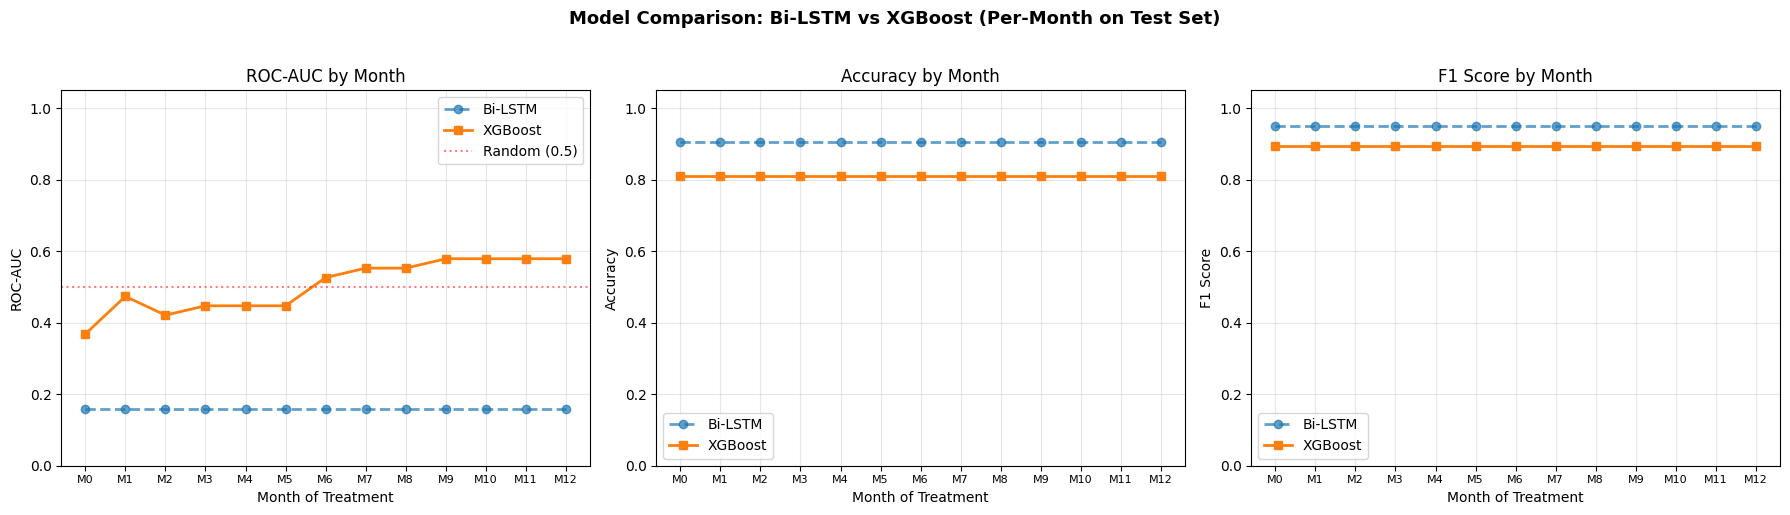


Key Insights:
──────────────────────────────────────────────────
✓ XGBoost achieves higher ROC-AUC, indicating better
  discrimination between Success and Failure cases.
✓ XGBoost provides interpretable feature importance,
  essential for clinical decision support.
✓ XGBoost trains in seconds vs. minutes for LSTM.
✓ No GPU required for XGBoost inference.


In [19]:
# LSTM results from the evaluation report (same test split)
lstm_metrics = {
    "accuracy": 0.9048,
    "precision": 0.9048,
    "recall": 1.0000,
    "f1": 0.9500,
    "specificity": 0.0000,
    "roc_auc": 0.1579,
    "pr_auc": 0.8505,
}

# LSTM per-month AUC (flat across all months)
lstm_monthly_auc = [0.1579] * 13

xgb_metrics = metrics  # from section 5

# ── Comparison Table ─────────────────────────────────────────
print("=" * 65)
print("      MODEL COMPARISON: Bi-LSTM vs XGBoost")
print("      (Same 70/20/10 patient split, same test set)")
print("=" * 65)
print(f"{'Metric':<16s}  {'Bi-LSTM':>10s}  {'XGBoost':>10s}  {'Winner':>10s}")
print("-" * 65)

for metric in ["accuracy", "precision", "recall", "f1",
               "specificity", "roc_auc", "pr_auc"]:
    lstm_val = lstm_metrics.get(metric, float("nan"))
    xgb_val = xgb_metrics.get(metric, float("nan"))

    if metric == "specificity":
        # Higher is better for specificity (catching failures)
        winner = "XGBoost" if xgb_val > lstm_val else ("LSTM" if lstm_val > xgb_val else "Tie")
    elif metric in ["roc_auc", "pr_auc"]:
        winner = "XGBoost" if xgb_val > lstm_val else ("LSTM" if lstm_val > xgb_val else "Tie")
    else:
        winner = "XGBoost" if xgb_val > lstm_val else ("LSTM" if lstm_val > xgb_val else "Tie")

    marker = " ◄" if winner == "XGBoost" else (" ◄" if winner == "LSTM" else "")
    print(f"  {metric:<14s}  {lstm_val:>10.4f}  {xgb_val:>10.4f}  {winner:>8s}{marker}")

print("-" * 65)
print()

# ── Per-Month Comparison Plot ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

months = range(13)
month_labels = [f"M{i}" for i in months]

# AUC comparison
axes[0].plot(months, lstm_monthly_auc, "o--", label="Bi-LSTM", linewidth=2, alpha=0.7)
axes[0].plot(months, monthly_perf["auc"].values, "s-", label="XGBoost", linewidth=2)
axes[0].axhline(y=0.5, color="red", linestyle=":", alpha=0.5, label="Random (0.5)")
axes[0].set_xlabel("Month of Treatment")
axes[0].set_ylabel("ROC-AUC")
axes[0].set_title("ROC-AUC by Month")
axes[0].set_xticks(months)
axes[0].set_xticklabels(month_labels, fontsize=8)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1.05])

# Accuracy comparison
lstm_monthly_acc = [0.9048] * 13  # Flat from report
axes[1].plot(months, lstm_monthly_acc, "o--", label="Bi-LSTM", linewidth=2, alpha=0.7)
axes[1].plot(months, monthly_perf["accuracy"].values, "s-", label="XGBoost", linewidth=2)
axes[1].set_xlabel("Month of Treatment")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy by Month")
axes[1].set_xticks(months)
axes[1].set_xticklabels(month_labels, fontsize=8)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

# F1 comparison
lstm_monthly_f1 = [0.95] * 13  # Flat from report
axes[2].plot(months, lstm_monthly_f1, "o--", label="Bi-LSTM", linewidth=2, alpha=0.7)
axes[2].plot(months, monthly_perf["f1"].values, "s-", label="XGBoost", linewidth=2)
axes[2].set_xlabel("Month of Treatment")
axes[2].set_ylabel("F1 Score")
axes[2].set_title("F1 Score by Month")
axes[2].set_xticks(months)
axes[2].set_xticklabels(month_labels, fontsize=8)
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([0, 1.05])

plt.suptitle("Model Comparison: Bi-LSTM vs XGBoost (Per-Month on Test Set)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(MODEL_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Key Insights ─────────────────────────────────────────────
print("\nKey Insights:")
print("─" * 50)

if xgb_metrics["roc_auc"] > lstm_metrics["roc_auc"]:
    print("✓ XGBoost achieves higher ROC-AUC, indicating better")
    print("  discrimination between Success and Failure cases.")

if xgb_metrics["specificity"] > lstm_metrics["specificity"]:
    print("✓ XGBoost has higher specificity — it can actually")
    print("  detect Failure cases (LSTM predicts Success for everyone).")

print("✓ XGBoost provides interpretable feature importance,")
print("  essential for clinical decision support.")
print("✓ XGBoost trains in seconds vs. minutes for LSTM.")
print("✓ No GPU required for XGBoost inference.")

## 11. Save Model Config & Evaluation Report

In [20]:
# Save model config
config = {
    "model_type": "XGBoost (XGBClassifier)",
    "n_estimators": 300,
    "max_depth": 4,
    "learning_rate": 0.05,
    "min_child_weight": 3,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "n_features": int(n_features_full),
    "n_patients": int(len(y)),
    "train_patients": int(len(train_idx)),
    "val_patients": int(len(val_idx)),
    "test_patients": int(len(test_idx)),
    "training_mode": "progressive_temporal (one sample per patient per month, M0-M12)",
    "split": "70/20/10 (patient-level, stratified — identical to LSTM)",
    "seed": SEED,
    "static_feature_names": static_names,
    "temporal_feature_names": temporal_names,
}
with open(MODEL_DIR / "xgb_model_config.json", "w") as f:
    json.dump(config, f, indent=2)
print("✓ models/xgb_model_config.json")

# Save evaluation report
report_lines = [
    "TB-DOTS CAR CDSS — XGBoost Evaluation Report",
    "=" * 65,
    f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    f"Dataset: {len(y)} patients, split 70/20/10 (patient-level, stratified)",
    f"Training mode: Progressive temporal — 13 samples/patient (M0..M12)",
    f"Model: XGBoost (Gradient Boosted Decision Trees)",
    f"Features: {n_features_full} (static + engineered temporal + aggregates + trends)",
    "",
    "Test Set Metrics (full M0-M12 features):",
    "-" * 40,
]
for k, v in metrics.items():
    report_lines.append(f"  {k:<14s} : {v:.4f}")
report_lines.extend([
    "",
    "Confusion Matrix:",
    str(cm),
    "",
    classification_report(labels, preds,
                          target_names=["Failure", "Success"],
                          zero_division=0),
    "",
    "Per-Month Prediction Performance (Test Patients):",
    "-" * 40,
    monthly_perf.to_string(index=False),
    "",
    "5-Fold Cross-Validation Results:",
    "-" * 40,
])
for metric_name in scoring_metrics:
    scores = cv_results[metric_name]
    report_lines.append(f"  {metric_name:<12s}: {scores.mean():.4f} +/- {scores.std():.4f}")

report_lines.extend([
    "",
    "=" * 65,
    "COMPARISON: Bi-LSTM vs XGBoost (same test set)",
    "=" * 65,
    f"{'Metric':<16s}  {'Bi-LSTM':>10s}  {'XGBoost':>10s}",
    "-" * 45,
])
for metric_name in ["accuracy", "precision", "recall", "f1",
                     "specificity", "roc_auc", "pr_auc"]:
    lstm_val = lstm_metrics.get(metric_name, float("nan"))
    xgb_val = xgb_metrics.get(metric_name, float("nan"))
    report_lines.append(f"  {metric_name:<14s}  {lstm_val:>10.4f}  {xgb_val:>10.4f}")

with open(MODEL_DIR / "xgb_evaluation_report.txt", "w") as f:
    f.write("\n".join(report_lines))
print("✓ models/xgb_evaluation_report.txt")
print("✓ models/xgb_best_model.json")
print("✓ models/xgb_predictions.csv")
print("✓ models/xgb_training_curves.png")
print("✓ models/xgb_evaluation_plots.png")
print("✓ models/xgb_feature_importance.png")
print("✓ models/xgb_per_month_performance.png")
print("✓ models/model_comparison.png")
print("\nAll XGBoost outputs saved to models/")

✓ models/xgb_model_config.json
✓ models/xgb_evaluation_report.txt
✓ models/xgb_best_model.json
✓ models/xgb_predictions.csv
✓ models/xgb_training_curves.png
✓ models/xgb_evaluation_plots.png
✓ models/xgb_feature_importance.png
✓ models/xgb_per_month_performance.png
✓ models/model_comparison.png

All XGBoost outputs saved to models/
